In [ ]:
# IMPORTANT:
#   Whenever you start a new colab runtime, use the following code to download
#   the training dataset onto the runtime local storage.
#   This should take ~3-5 mins for the whole dataset.
#   You can then load data from the local storage (/content/data) into your colab
#   notebook using the `h5py` library (see example below).
from huggingface_hub import hf_hub_download
hf_hub_download(repo_id="benmoseley/ese-dl-2024-25-group-project", filename="train.h5", repo_type="dataset", local_dir="data")
hf_hub_download(repo_id="benmoseley/ese-dl-2024-25-group-project", filename="events.csv", repo_type="dataset", local_dir="data")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


train.h5:   0%|          | 0.00/10.7G [00:00<?, ?B/s]

events.csv:   0%|          | 0.00/782k [00:00<?, ?B/s]

'data/events.csv'

In [ ]:
import pandas as pd
import h5py
import IPython
import PIL
import matplotlib.pyplot as plt
import os
import io
import random
from torch.utils.data import Subset
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
import time
import torch.optim as optim
from torch.nn import L1Loss
import imageio
import numpy as np
from torchvision.transforms.functional import to_pil_image
from PIL import Image, ImageDraw, ImageFont

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# this DataFrame contains all of the event meta data
df = pd.read_csv("data/events.csv", parse_dates=["start_utc"])
df

,id,img_type,start_utc,llcrnrlat,llcrnrlon,urcrnrlat,urcrnrlon,proj,height_m,width_m
0,S778114,ir069,2018-08-20 19:50:00+00:00,32.781533,-92.631841,35.944590,-88.134075,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
1,S778114,ir107,2018-08-20 19:50:00+00:00,32.781533,-92.631841,35.944590,-88.134075,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
2,S778114,lght,NaT,32.781533,-92.631841,35.944590,-88.134075,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
3,S778114,vil,2018-08-20 19:50:00+00:00,32.781533,-92.631841,35.944590,-88.134075,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
4,S778114,vis,2018-08-20 19:50:00+00:00,32.781533,-92.631841,35.944590,-88.134075,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
...,...,...,...,...,...,...,...,...,...,...
3995,S832818,ir069,2019-07-28 17:44:00+00:00,46.493514,-100.371384,49.953392,-95.191216,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
3996,S832818,ir107,2019-07-28 17:44:00+00:00,46.493514,-100.371384,49.953392,-95.191216,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
3997,S832818,lght,NaT,46.493514,-100.371384,49.953392,-95.191216,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
3998,S832818,vil,2019-07-28 17:45:00+00:00,46.493514,-100.371384,49.953392,-95.191216,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0


### Baseline Unet

In [ ]:
import h5py

# This function loads all of the image arrays for a given id
def load_event(id, img_type='vis', h5_file='data/train.h5'):
    """Load event for a specific image type"""
    with h5py.File(h5_file, 'r') as f:
        event = {img_type: f[id][img_type][:] for img_type in [img_type]}
    return event

# Load a specific event (example event ID "S778114")
event_id = "S778114"
event = load_event(event_id)

# Check the shape of the 'vis' data
print(f"vis: {event['vis'].shape} ({event['vis'].dtype})")


vis: (384, 384, 36) (int16)


In [ ]:
def standard_normalize(data):
    """
    Standard normalization: (data - mean) / std.
    Avoid division by zero by adding a small epsilon to std.
    """
    mean = np.mean(data)
    std = np.std(data)
    return (data - mean) / (std + 1e-8)

In [ ]:
import torch
from torch.utils.data import Dataset
import h5py
import numpy as np

class H5Dataset(Dataset):
    def __init__(self, h5_file, img_type='vis', input_frames=12, output_frames=12, height=384, width=384):
        """
        Args:
            h5_file (str): Path to the .h5 file.
            img_type (str): The image type to load (e.g., 'vis', 'ir069').
            input_frames (int): Number of input frames (e.g., 12).
            output_frames (int): Number of output frames (e.g., 12).
            height (int): Height of each frame.
            width (int): Width of each frame.
        """
        self.h5_file = h5_file
        self.img_type = img_type
        self.input_frames = input_frames
        self.output_frames = output_frames
        self.height = height
        self.width = width

        # Load the .h5 file and extract the event IDs
        with h5py.File(self.h5_file, 'r') as f:
            self.event_ids = list(f.keys())  # All event IDs available in the .h5 file

    def __len__(self):
        """Returns the total number of samples"""
        return len(self.event_ids)

    def __getitem__(self, idx):
        """Load event, split into input-output pairs directly from the .h5 file"""
        event_id = self.event_ids[idx]

        with h5py.File(self.h5_file, 'r') as f:
            event_data = f[event_id][self.img_type][:]  # Shape: (384, 384, 36)

        # Extract the first 12 frames as input and the next 12 frames as output
        input_data = event_data[:, :, :self.input_frames]  # First 12 frames as input
        output_data = event_data[:, :, self.input_frames:self.input_frames+self.output_frames]  # Next 12 frames as output

        # Normalize the data (standard normalization)
        input_data = standard_normalize(input_data)
        output_data = standard_normalize(output_data)

        # Convert data to PyTorch tensors
        input_data = torch.tensor(input_data, dtype=torch.float32)
        output_data = torch.tensor(output_data, dtype=torch.float32)

        # Reshape data to match expected input shape (batch_size, input_frames, height, width)
        input_data = input_data.permute(2, 0, 1)  # (input_frames, height, width) -> (batch_size, input_frames, height, width)
        output_data = output_data.permute(2, 0, 1)  # (output_frames, height, width) -> (batch_size, output_frames, height, width)

        # Reshape data to match expected input shape (batch_size, channels, depth, height, width)
        input_data = input_data.unsqueeze(1)  # Add a channel dimension
        output_data = output_data.unsqueeze(1)  # Add a channel dimension

        return {'input': input_data, 'output': output_data}

In [ ]:
h5_file = 'data/train.h5'  # Path to your .h5 file
img_type = 'vis'  # The image type you want to load (e.g., 'vis', 'ir069', etc.)
data_example = H5Dataset(h5_file, img_type='vis', input_frames=12, output_frames=12, height=384, width=384)
len(data_example)

800

In [ ]:
data_example[0]['input'].shape, data_example[0]['output'].shape

(torch.Size([12, 1, 384, 384]), torch.Size([12, 1, 384, 384]))

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

class UNet(nn.Module):
    def __init__(self, input_channels=12, output_channels=12):
        super(UNet, self).__init__()

        # Encoding path
        self.enc_conv1 = nn.Conv2d(input_channels, 64, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.enc_conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.enc_conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Bottleneck
        self.bottleneck = nn.Conv2d(256, 512, kernel_size=3, padding=1)

        # Decoding path using ConvTranspose2d instead of Upsample
        self.up1 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)  # Transposed conv instead of bilinear upsample
        self.dec_conv1 = nn.Conv2d(512, 256, kernel_size=3, padding=1)  # 512 comes from skip connection concat

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec_conv2 = nn.Conv2d(256, 128, kernel_size=3, padding=1)

        self.up3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec_conv3 = nn.Conv2d(128, 64, kernel_size=3, padding=1)

        # Output layer
        self.output_layer = nn.Conv2d(64, output_channels, kernel_size=1)  # Linear activation (no ReLU)

    def forward(self, x):
        # Encoding path
        enc1 = torch.relu(self.enc_conv1(x))
        pool1 = self.pool1(enc1)

        enc2 = torch.relu(self.enc_conv2(pool1))
        pool2 = self.pool2(enc2)

        enc3 = torch.relu(self.enc_conv3(pool2))
        pool3 = self.pool3(enc3)

        # Bottleneck
        bottleneck = torch.relu(self.bottleneck(pool3))

        # Decoding path using transposed convolutions
        up1 = self.up1(bottleneck)
        concat1 = torch.cat([up1, enc3], dim=1)
        dec1 = torch.relu(self.dec_conv1(concat1))

        up2 = self.up2(dec1)
        concat2 = torch.cat([up2, enc2], dim=1)
        dec2 = torch.relu(self.dec_conv2(concat2))

        up3 = self.up3(dec2)
        concat3 = torch.cat([up3, enc1], dim=1)
        dec3 = torch.relu(self.dec_conv3(concat3))

        # Output layer
        outputs = self.output_layer(dec3)
        return outputs


# Instantiate the model
input_channels = 12  # 12 frames
output_channels = 12  # Predicting 12 output frames
model = UNet(input_channels=input_channels, output_channels=output_channels)

# Example input tensor
batch_size = 8
temporal_frames = 12
features_per_frame = 4  # Assuming 4 features per frame
height, width = 384, 384

# Creating input in (batch, channels, height, width) format
example_input = torch.randn(batch_size, temporal_frames, height, width)

# Forward pass
output = model(example_input)
print("Output shape:", output.shape)  # Expected: (8, 12, 384, 384)


Output shape: torch.Size([8, 12, 384, 384])


In [ ]:
from torchvision import models
from torchsummary import summary
from torchsummary import summary


input_channels = 12
output_channels = 12
model = UNet(input_channels=input_channels, output_channels=output_channels)
summary(model, input_size=(12, 384, 384), device="cpu")

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 384, 384]           6,976
         MaxPool2d-2         [-1, 64, 192, 192]               0
            Conv2d-3        [-1, 128, 192, 192]          73,856
         MaxPool2d-4          [-1, 128, 96, 96]               0
            Conv2d-5          [-1, 256, 96, 96]         295,168
         MaxPool2d-6          [-1, 256, 48, 48]               0
            Conv2d-7          [-1, 512, 48, 48]       1,180,160
   ConvTranspose2d-8          [-1, 256, 96, 96]         524,544
            Conv2d-9          [-1, 256, 96, 96]       1,179,904
  ConvTranspose2d-10        [-1, 128, 192, 192]         131,200
           Conv2d-11        [-1, 128, 192, 192]         295,040
  ConvTranspose2d-12         [-1, 64, 384, 384]          32,832
           Conv2d-13         [-1, 64, 384, 384]          73,792
           Conv2d-14         [-1, 12, 3

Does U-Net Capture Temporal Information?

Yes, but indirectly.
- The spatial convolutional layers in U-Net extract patterns from the entire input volume (which includes time frames).
- By stacking multiple time frames as channels, the network implicitly learns relationships between consecutive frames.

However, the limitation is:
- A 2D U-Net does not model time explicitly—it processes frames as independent spatial features rather than as a sequence.
- It assumes temporal dependencies exist within spatial patterns but does not explicitly track order or motion dynamics.

In [ ]:
def split_data(event_ids, train_ratio=0.8):
    random.shuffle(event_ids)  # Shuffle event IDs
    split_idx = int(len(event_ids) * train_ratio)
    train_ids = event_ids[:split_idx]
    val_ids = event_ids[split_idx:]
    return train_ids, val_ids

In [ ]:
from torch.utils.data import DataLoader
import random
from torch.utils.data import Subset

# Example of loading the data from .h5 file directly using the custom Dataset class
h5_file = 'data/train.h5'  # Path to your .h5 file
img_type = 'vil'  # The image type you want to load (e.g., 'vis', 'ir069', etc.)

# Initialize the dataset
dataset = H5Dataset(h5_file=h5_file, img_type=img_type, input_frames=12, output_frames=12)

# Split the loaded data into train and validation sets
train_ids, val_ids = split_data(dataset.event_ids, train_ratio=0.8)

# Instead of directly using event IDs, use their indices
train_indices = [dataset.event_ids.index(event_id) for event_id in train_ids]
val_indices = [dataset.event_ids.index(event_id) for event_id in val_ids]

# Create the training and validation datasets
train_dataset = Subset(dataset, train_indices)  # Use train_indices instead of train_ids
val_dataset = Subset(dataset, val_indices)  # Use val_indices instead of val_ids

batch_size = 64

# Create DataLoaders for training and validation
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Check the shape of the data
for batch in train_loader:
    inputs, targets = batch['input'], batch['output']
    print(f"Input shape: {inputs.shape}, Output shape: {targets.shape}")
    break

reshaped_inputs = inputs.view(batch_size, temporal_frames, height, width)
reshaped_outputs = targets.view(batch_size, temporal_frames, height, width)


print(reshaped_inputs.shape)
print(reshaped_outputs.shape)

Input shape: torch.Size([64, 12, 1, 384, 384]), Output shape: torch.Size([64, 12, 1, 384, 384])
torch.Size([64, 12, 384, 384])
torch.Size([64, 12, 384, 384])


In [ ]:
total_samples_train = len(train_dataset)
total_samples_val = len(val_dataset)

print(f"Total samples in train_dataset1: {total_samples_train}")
print(f"Total samples in val_dataset1: {total_samples_val}")

Total samples in train_dataset1: 640
Total samples in val_dataset1: 160


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import torch

save_dir = "/content/drive/MyDrive/saved_model_unet"
os.makedirs(save_dir, exist_ok=True)
best_model_path = os.path.join(save_dir, "best_model_unet.pth")
final_model_path = os.path.join(save_dir, "final_model_unet.pth")

Using device: cuda
Epoch [1/5], Training Loss: 0.5483853936195373
Validation Loss: 0.451071431239446
Epoch [2/5], Training Loss: 0.4252138018608093
Validation Loss: 0.42644890149434406
Epoch [3/5], Training Loss: 0.4097540110349655
Validation Loss: 0.399492879708608
Epoch [4/5], Training Loss: 0.38351571261882783
Validation Loss: 0.3749001125494639
Epoch [5/5], Training Loss: 0.3672844886779785
Validation Loss: 0.3607794940471649
Final trained model saved at /content/drive/MyDrive/saved_model_unet/final_model_unet.pth


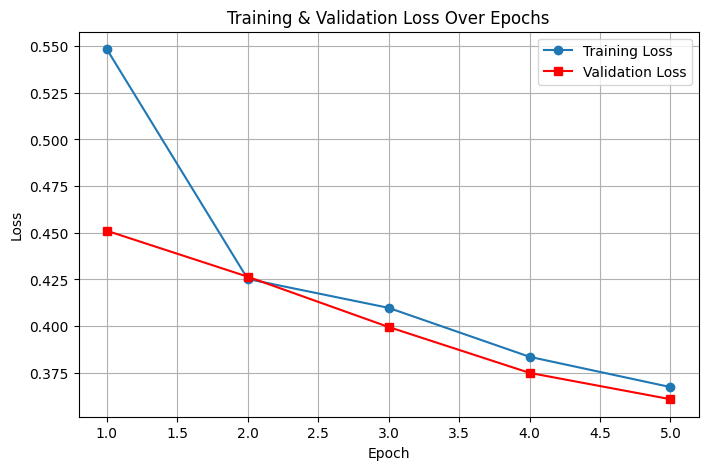

In [ ]:
# Check if a GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Instantiate the U-Net model and move it to the selected device
model = UNet(input_channels=12, output_channels=12).to(device)

# Define the loss function and optimizer
criterion = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Store loss values for plotting
train_losses = []
val_losses = []

# Training loop with loss tracking
num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for batch in train_loader:
        inputs, targets = batch['input'].to(device), batch['output'].to(device)  # Move tensors to device
        inputs = inputs.view(batch_size, temporal_frames, height, width)
        targets = targets.view(batch_size, temporal_frames, height, width)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(inputs)

        # Calculate loss
        loss = criterion(outputs, targets)
        running_loss += loss.item()

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    print(f"Epoch [{epoch+1}/{num_epochs}], Training Loss: {epoch_loss}")

    # Evaluate on validation set
    model.eval()
    with torch.no_grad():
        val_loss = 0.0
        for batch in val_loader:
            inputs, targets = batch['input'].to(device), batch['output'].to(device)  # Move tensors to device
            inputs = inputs.view(inputs.shape[0], temporal_frames, height, width)
            targets = targets.view(inputs.shape[0], temporal_frames, height, width)

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        print(f"Validation Loss: {avg_val_loss}")


    # Save the best model if validation loss improves
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_val_loss
        }, best_model_path)
        print(f"Best model saved at epoch {epoch+1} with Validation Loss: {avg_val_loss:.6f}")

# Save the final trained model
torch.save({
    'epoch': num_epochs,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': avg_val_loss
}, final_model_path)
print(f"Final trained model saved at {final_model_path}")

# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_losses, marker='o', linestyle='-', label="Training Loss")
plt.plot(range(1, num_epochs + 1), val_losses, marker='s', linestyle='-', color='red', label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss Over Epochs")
plt.grid(True)
plt.legend()
plt.show()


<ipython-input-92-ecd21f8decc4>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("/content/drive/MyDrive/saved_model_unet/final_model_unet.pth")
<ipy

Input shape after squeeze: torch.Size([64, 12, 384, 384]), Target shape after squeeze: torch.Size([64, 12, 384, 384])


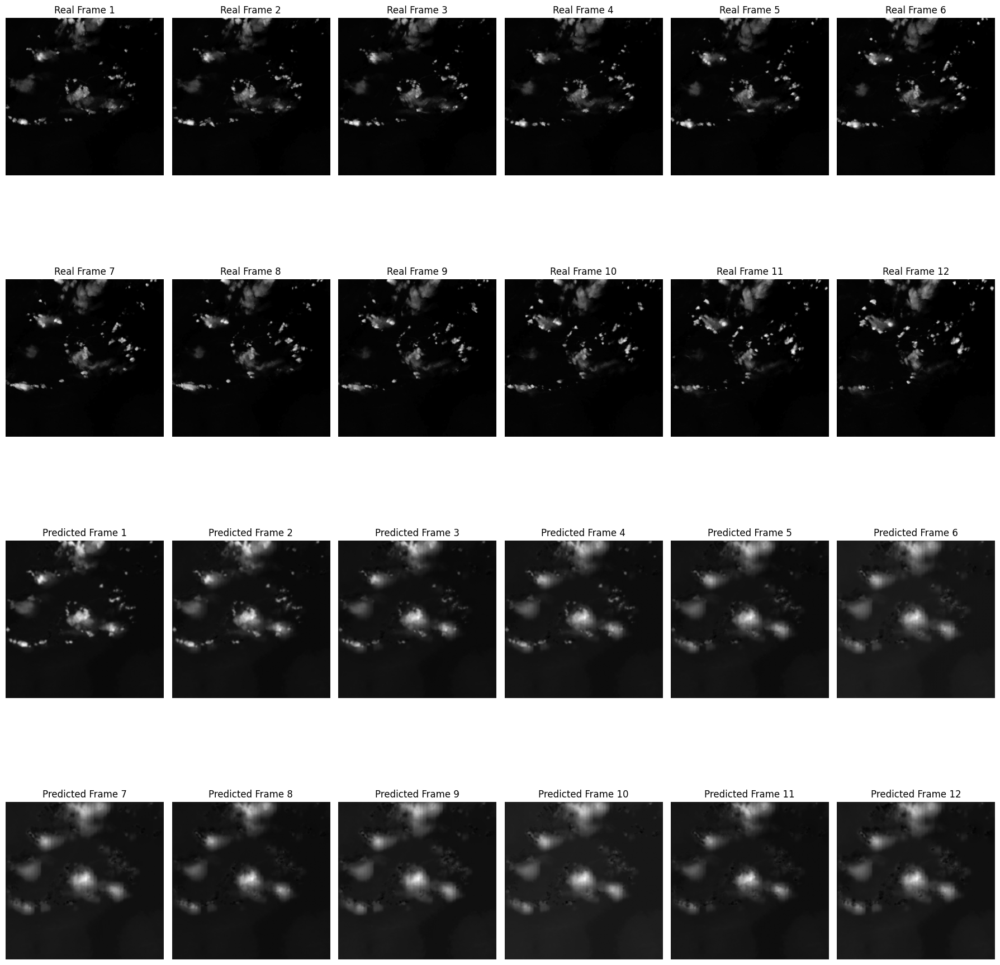

In [ ]:
# Load the trained model
model = UNet(input_channels=12, output_channels=12).to(device)
checkpoint = torch.load("/content/drive/MyDrive/saved_model_unet/final_model_unet.pth")
checkpoint = torch.load(final_model_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Get the first batch from the validation loader
for batch_idx, batch in enumerate(val_loader):  # Use ⁠ val_loader1 ⁠ or test DataLoader
    if batch_idx == 0:  # Only process the first batch
        # Get inputs and targets, remove the singleton channel dimension
        inputs, targets = batch['input'].to(device), batch['output'].to(device)

        # Reshape the input and output tensors to remove the channel dimension
        inputs = inputs.squeeze(2)  # Reshape from [batch_size, temporal_frames, 1, height, width] to [batch_size, temporal_frames, height, width]
        targets = targets.squeeze(2)  # Same for the target

        print(f"Input shape after squeeze: {inputs.shape}, Target shape after squeeze: {targets.shape}")

        # Make predictions using the model
        with torch.no_grad():  # No need to calculate gradients for predictions
            predicted_output = model(inputs)  # Pass the input data through the model

        # Visualize the comparison of the predicted vs real output for all 12 frames
        num_frames = 12  # Total frames in the sequence (12 frames)

        # Create a figure with 4 rows and 6 columns
        plt.figure(figsize=(18, 20))  # Adjusted figure size for four rows of 6 images

        # Plot the real output frames (ground truth) in the first two rows
        for frame_idx in range(num_frames):
            # Plot in the first 2 rows, 6 columns
            plt.subplot(4, 6, frame_idx + 1)  # 4 rows, 6 columns, first row
            plt.imshow(targets[0, frame_idx, :, :].cpu().numpy(), cmap='gray')  # Real output frame
            plt.title(f'Real Frame {frame_idx + 1}')
            plt.axis('off')

        # Plot the predicted output frames starting from the 3rd row
        for frame_idx in range(num_frames):
            # Plot in the 3rd and 4th rows, 6 columns
            plt.subplot(4, 6, 12 + frame_idx + 1)  # 4 rows, 6 columns, 3rd row
            plt.imshow(predicted_output[0, frame_idx, :, :].cpu().numpy(), cmap='gray')  # Predicted frame
            plt.title(f'Predicted Frame {frame_idx + 1}')
            plt.axis('off')

        plt.tight_layout()  # Adjust layout
        plt.show()



### Min-max

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import torch

save_dir = "/content/drive/MyDrive/saved_model_unet_minmax"
os.makedirs(save_dir, exist_ok=True)
best_model_path = os.path.join(save_dir, "best_model_unet.pth")
final_model_path = os.path.join(save_dir, "final_model_unet.pth")

In [ ]:
def min_max(data):
    """
    Min-max normalization: (data - min) / (max - min).
    """
    min_val = np.min(data)
    max_val = np.max(data)
    return (data - min_val) / (max_val - min_val)

In [ ]:
import torch
from torch.utils.data import Dataset
import h5py
import numpy as np

class H5Dataset(Dataset):
    def __init__(self, h5_file, img_type='vis', input_frames=12, output_frames=12, height=384, width=384):
        """
        Args:
            h5_file (str): Path to the .h5 file.
            img_type (str): The image type to load (e.g., 'vis', 'ir069').
            input_frames (int): Number of input frames (e.g., 12).
            output_frames (int): Number of output frames (e.g., 12).
            height (int): Height of each frame.
            width (int): Width of each frame.
        """
        self.h5_file = h5_file
        self.img_type = img_type
        self.input_frames = input_frames
        self.output_frames = output_frames
        self.height = height
        self.width = width

        # Load the .h5 file and extract the event IDs
        with h5py.File(self.h5_file, 'r') as f:
            self.event_ids = list(f.keys())  # All event IDs available in the .h5 file

    def __len__(self):
        """Returns the total number of samples"""
        return len(self.event_ids)

    def __getitem__(self, idx):
        """Load event, split into input-output pairs directly from the .h5 file"""
        event_id = self.event_ids[idx]

        with h5py.File(self.h5_file, 'r') as f:
            event_data = f[event_id][self.img_type][:]  # Shape: (384, 384, 36)

        # Extract the first 12 frames as input and the next 12 frames as output
        input_data = event_data[:, :, :self.input_frames]  # First 12 frames as input
        output_data = event_data[:, :, self.input_frames:self.input_frames+self.output_frames]  # Next 12 frames as output

        # Normalize the data (standard normalization)
        input_data = min_max(input_data)
        output_data = min_max(output_data)

        # Convert data to PyTorch tensors
        input_data = torch.tensor(input_data, dtype=torch.float32)
        output_data = torch.tensor(output_data, dtype=torch.float32)

        # Reshape data to match expected input shape (batch_size, input_frames, height, width)
        input_data = input_data.permute(2, 0, 1)  # (input_frames, height, width) -> (batch_size, input_frames, height, width)
        output_data = output_data.permute(2, 0, 1)  # (output_frames, height, width) -> (batch_size, output_frames, height, width)

        # Reshape data to match expected input shape (batch_size, channels, depth, height, width)
        input_data = input_data.unsqueeze(1)  # Add a channel dimension
        output_data = output_data.unsqueeze(1)  # Add a channel dimension

        return {'input': input_data, 'output': output_data}

In [ ]:
# Example of loading the data from .h5 file directly using the custom Dataset class
h5_file = 'data/train.h5'  # Path to your .h5 file
img_type = 'vil'  # The image type you want to load (e.g., 'vis', 'ir069', etc.)

# Initialize the dataset
dataset = H5Dataset(h5_file=h5_file, img_type=img_type, input_frames=12, output_frames=12)

# Split the loaded data into train and validation sets
train_ids, val_ids = split_data(dataset.event_ids, train_ratio=0.8)

# Instead of directly using event IDs, use their indices
train_indices = [dataset.event_ids.index(event_id) for event_id in train_ids]
val_indices = [dataset.event_ids.index(event_id) for event_id in val_ids]

# Create the training and validation datasets
train_dataset = Subset(dataset, train_indices)  # Use train_indices instead of train_ids
val_dataset = Subset(dataset, val_indices)  # Use val_indices instead of val_ids

batch_size = 64

# Create DataLoaders for training and validation
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Check the shape of the data
for batch in train_loader:
    inputs, targets = batch['input'], batch['output']
    print(f"Input shape: {inputs.shape}, Output shape: {targets.shape}")
    break

temporal_frames = 12
height, width = 384, 384
reshaped_inputs = inputs.view(batch_size, temporal_frames, height, width)
reshaped_outputs = targets.view(batch_size, temporal_frames, height, width)


print(reshaped_inputs.shape)
print(reshaped_outputs.shape)

Input shape: torch.Size([64, 12, 1, 384, 384]), Output shape: torch.Size([64, 12, 1, 384, 384])
torch.Size([64, 12, 384, 384])
torch.Size([64, 12, 384, 384])


Using device: cuda
Epoch [1/5], Training Loss: 0.09464309513568878
Validation Loss: 0.07652941594521205
Best model saved at epoch 1 with Validation Loss: 0.076529
Epoch [2/5], Training Loss: 0.07116674780845642
Validation Loss: 0.07027761389811833
Best model saved at epoch 2 with Validation Loss: 0.070278
Epoch [3/5], Training Loss: 0.06600713841617108
Validation Loss: 0.06842436144749324
Best model saved at epoch 3 with Validation Loss: 0.068424
Epoch [4/5], Training Loss: 0.0648786649107933
Validation Loss: 0.0642086590329806
Best model saved at epoch 4 with Validation Loss: 0.064209
Epoch [5/5], Training Loss: 0.059883037209510805
Validation Loss: 0.05946565171082815
Best model saved at epoch 5 with Validation Loss: 0.059466
Final trained model saved at /content/drive/MyDrive/saved_model_unet_minmax/final_model_unet.pth


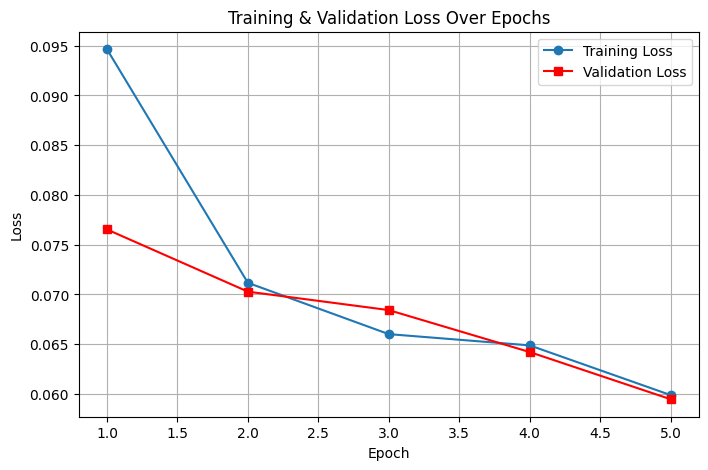

In [ ]:
# Check if a GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Instantiate the U-Net model and move it to the selected device
model = UNet(input_channels=12, output_channels=12).to(device)

# Define the loss function and optimizer
criterion = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Store loss values for plotting
train_losses = []
val_losses = []

# Training loop with loss tracking
num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for batch in train_loader:
        inputs, targets = batch['input'].to(device), batch['output'].to(device)  # Move tensors to device
        inputs = inputs.view(batch_size, temporal_frames, height, width)
        targets = targets.view(batch_size, temporal_frames, height, width)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(inputs)

        # Calculate loss
        loss = criterion(outputs, targets)
        running_loss += loss.item()

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    print(f"Epoch [{epoch+1}/{num_epochs}], Training Loss: {epoch_loss}")

    # Evaluate on validation set
    model.eval()
    with torch.no_grad():
        val_loss = 0.0
        for batch in val_loader:
            inputs, targets = batch['input'].to(device), batch['output'].to(device)  # Move tensors to device
            inputs = inputs.view(inputs.shape[0], temporal_frames, height, width)
            targets = targets.view(inputs.shape[0], temporal_frames, height, width)

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        print(f"Validation Loss: {avg_val_loss}")


    # Save the best model if validation loss improves
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_val_loss
        }, best_model_path)
        print(f"Best model saved at epoch {epoch+1} with Validation Loss: {avg_val_loss:.6f}")

# Save the final trained model
torch.save({
    'epoch': num_epochs,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': avg_val_loss
}, final_model_path)
print(f"Final trained model saved at {final_model_path}")

# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_losses, marker='o', linestyle='-', label="Training Loss")
plt.plot(range(1, num_epochs + 1), val_losses, marker='s', linestyle='-', color='red', label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss Over Epochs")
plt.grid(True)
plt.legend()
plt.show()

<ipython-input-104-55a1e0586e44>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("/content/drive/MyDrive/saved_model_unet_minmax/final_model_unet.pt

Input shape after squeeze: torch.Size([64, 12, 384, 384]), Target shape after squeeze: torch.Size([64, 12, 384, 384])


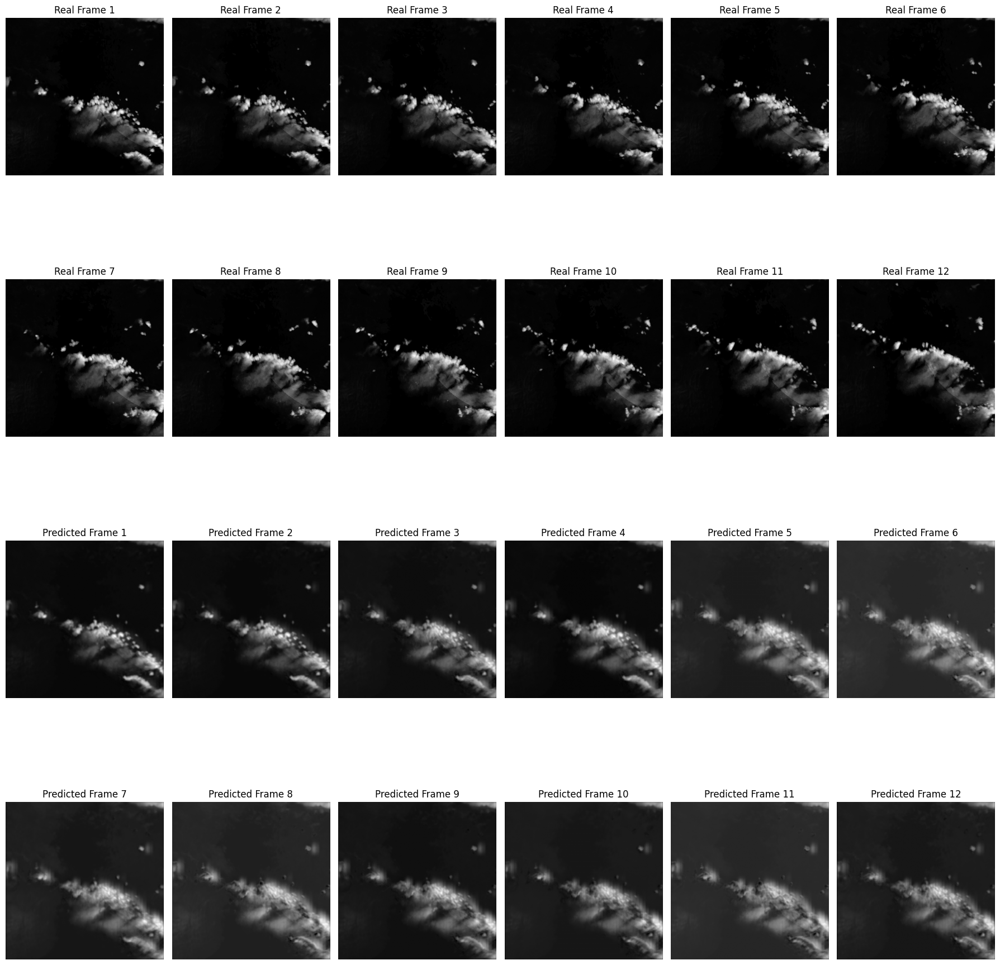

Mean Squared Error: 0.060274407267570496


In [ ]:
# Load the trained model
model = UNet(input_channels=12, output_channels=12).to(device)
checkpoint = torch.load("/content/drive/MyDrive/saved_model_unet_minmax/final_model_unet.pth")
checkpoint = torch.load(final_model_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Get the first batch from the validation loader
for batch_idx, batch in enumerate(val_loader):  # Use ⁠ val_loader1 ⁠ or test DataLoader
    if batch_idx == 0:  # Only process the first batch
        # Get inputs and targets, remove the singleton channel dimension
        inputs, targets = batch['input'].to(device), batch['output'].to(device)

        # Reshape the input and output tensors to remove the channel dimension
        inputs = inputs.squeeze(2)  # Reshape from [batch_size, temporal_frames, 1, height, width] to [batch_size, temporal_frames, height, width]
        targets = targets.squeeze(2)  # Same for the target

        print(f"Input shape after squeeze: {inputs.shape}, Target shape after squeeze: {targets.shape}")

        # Make predictions using the model
        with torch.no_grad():  # No need to calculate gradients for predictions
            predicted_output = model(inputs)  # Pass the input data through the model

        # Visualize the comparison of the predicted vs real output for all 12 frames
        num_frames = 12  # Total frames in the sequence (12 frames)

        # Create a figure with 4 rows and 6 columns
        plt.figure(figsize=(18, 20))  # Adjusted figure size for four rows of 6 images

        # Plot the real output frames (ground truth) in the first two rows
        for frame_idx in range(num_frames):
            # Plot in the first 2 rows, 6 columns
            plt.subplot(4, 6, frame_idx + 1)  # 4 rows, 6 columns, first row
            plt.imshow(targets[0, frame_idx, :, :].cpu().numpy(), cmap='gray')  # Real output frame
            plt.title(f'Real Frame {frame_idx + 1}')
            plt.axis('off')

        # Plot the predicted output frames starting from the 3rd row
        for frame_idx in range(num_frames):
            # Plot in the 3rd and 4th rows, 6 columns
            plt.subplot(4, 6, 12 + frame_idx + 1)  # 4 rows, 6 columns, 3rd row
            plt.imshow(predicted_output[0, frame_idx, :, :].cpu().numpy(), cmap='gray')  # Predicted frame
            plt.title(f'Predicted Frame {frame_idx + 1}')
            plt.axis('off')

        plt.tight_layout()  # Adjust layout
        plt.show()

        l1_loss = torch.nn.L1Loss()(predicted_output, targets)
        print(f'Mean Squared Error: {l1_loss.item()}')

        break  # Only process the first batch, stop after the first batch


### Sliding window

In [ ]:
# create another directory
import os
import torch

save_dir = "/content/drive/MyDrive/saved_model_unet_window"
os.makedirs(save_dir, exist_ok=True)
best_model_path = os.path.join(save_dir, "best_model_unet_batch.pth")
final_model_path = os.path.join(save_dir, "final_model_unet.pth")

In [ ]:
import torch
import h5py
import numpy as np
from torch.utils.data import Dataset

class H5Dataset1(Dataset):
    def __init__(self, h5_file, img_type='vil', input_frames=12, output_frames=12, height=384, width=384, stride=1):
        """
        Implements a sliding window dataset from an HDF5 file.

        Args:
            h5_file (str): Path to the .h5 file.
            img_type (str): The image type to load (e.g., 'vis', 'ir069').
            input_frames (int): Number of input frames (e.g., 12).
            output_frames (int): Number of output frames (e.g., 12).
            height (int): Height of each frame.
            width (int): Width of each frame.
            stride (int): Step size for the sliding window (e.g., 1 moves by 1 frame each time).
        """
        self.h5_file = h5_file
        self.img_type = img_type
        self.input_frames = input_frames
        self.output_frames = output_frames
        self.height = height
        self.width = width
        self.stride = stride  # Number of frames to shift the window

        # Keep the HDF5 file open
        self.h5_file_handle = h5py.File(self.h5_file, 'r')

        # Load event IDs
        self.event_ids = list(self.h5_file_handle.keys())

        # Compute valid sequence indices using a sliding window
        self.sequence_indices = self._generate_sequence_indices()

    def _generate_sequence_indices(self):
        """Generate all valid (event_id, start_frame) pairs for the sliding window."""
        sequence_indices = []
        for event_id in self.event_ids:
            event_data = self.h5_file_handle[event_id][self.img_type]  # Access data using the file handle
            num_frames = event_data.shape[2]

            # Ensure we have enough frames for at least one full sequence
            max_start_frame = num_frames - (self.input_frames + self.output_frames)
            if max_start_frame >= 0:
                for start_frame in range(0, max_start_frame + 1, self.stride):
                    sequence_indices.append((event_id, start_frame))

        return sequence_indices

    def __len__(self):
        """Returns the total number of sliding window samples."""
        return len(self.sequence_indices)

    def __getitem__(self, idx):
        """Load event and extract input-output sequence from sliding window."""
        event_id, start_frame = self.sequence_indices[idx]

        # Access data using the file handle
        event_data = self.h5_file_handle[event_id][self.img_type]

        # Extract frames using the sliding window
        input_data = event_data[:, :, start_frame:start_frame + self.input_frames]
        output_data = event_data[:, :, start_frame + self.input_frames:start_frame + self.input_frames + self.output_frames]

        # Normalize input and output
        input_data = (input_data - input_data.min()) / (input_data.max() -  input_data.min())
        output_data = (output_data - output_data.min()) / (output_data.max() + input_data.min())

        # Convert data to PyTorch tensors
        input_data = torch.tensor(input_data, dtype=torch.float32)
        output_data = torch.tensor(output_data, dtype=torch.float32)

        # Reshape to match (channels, depth, height, width)
        input_data = input_data.permute(2, 0, 1).unsqueeze(1)
        output_data = output_data.permute(2, 0, 1).unsqueeze(1)

        return {'input': input_data, 'output': output_data}

    def __del__(self):
        """Close the HDF5 file when the dataset object is deleted."""
        self.h5_file_handle.close()

Using device: cuda
Epoch [1/5], Training Loss: 0.075973


<ipython-input-11-9f74dbdfba89>:88: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Validation Loss: 0.055728
Best model saved at epoch 1 with Validation Loss: 0.055728
Epoch [2/5], Training Loss: 0.053436
Validation Loss: 0.052130
Best model saved at epoch 2 with Validation Loss: 0.052130
Epoch [3/5], Training Loss: 0.050828
Validation Loss: 0.051164
Best model saved at epoch 3 with Validation Loss: 0.051164
Epoch [4/5], Training Loss: 0.049809
Validation Loss: 0.049085
Best model saved at epoch 4 with Validation Loss: 0.049085
Epoch [5/5], Training Loss: 0.048942
Validation Loss: 0.048334
Best model saved at epoch 5 with Validation Loss: 0.048334
Final trained model saved at /content/drive/MyDrive/saved_model_unet_window/final_model_unet.pth
Mixed Precision Training Completed: Training Time: 923.73 seconds


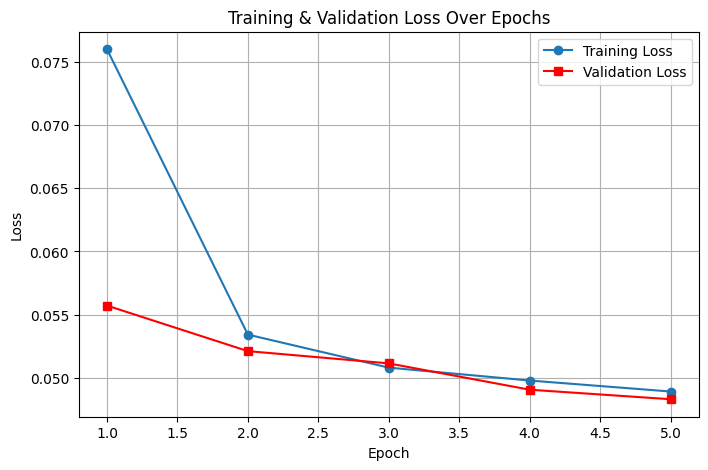

In [ ]:
import torch
import torch.optim as optim
import os
import time
from torch.utils.data import DataLoader, Subset
import random

# Load data
h5_file = 'data/train.h5'  # Path to your .h5 file
img_type = 'vil'  # The image type you want to load (e.g., 'vis', 'ir069', etc.)

# Define datasets
dataset1 = H5Dataset1(h5_file=h5_file, img_type=img_type, input_frames=12, output_frames=12, height=384, width=384)
all_indices = list(range(len(dataset1)))
train_indices1, val_indices1 = split_data(all_indices, train_ratio=0.8)
train_dataset1 = Subset(dataset1, train_indices1)
val_dataset1 = Subset(dataset1, val_indices1)

# Define dataloaders
batch_size = 64
train_loader1 = DataLoader(train_dataset1, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_loader1 = DataLoader(val_dataset1, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

# Device to cuda
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Initialise the model
model = UNet(input_channels=12, output_channels=12).to(device)

# Optimiser, scaler, AMP (Mixed Precision )
optimizer = optim.Adam(model.parameters(), lr=1e-4)
use_amp = True  # Set to False if you want to compare with normal precision
scaler = torch.amp.GradScaler(device='cuda', enabled=use_amp)
criterion = torch.nn.L1Loss()

# Functions for timer
def start_timer():
    global start_time
    start_time = time.time()

def end_timer_and_print(msg):
    elapsed_time = time.time() - start_time
    print(f"{msg} Training Time: {elapsed_time:.2f} seconds")

# Initilise loop with epoch number and lists to store losses
best_val_loss = float("inf")
num_epochs = 5
train_losses, val_losses = [], []

start_timer()
for epoch in range(num_epochs):
    # Train
    model.train()
    running_loss = 0.0

    for batch in train_loader1:
        inputs, targets = batch['input'].to(device), batch['output'].to(device)
        inputs = inputs.view(batch_size, temporal_frames, height, width)
        targets = targets.view(batch_size, temporal_frames, height, width)
        optimizer.zero_grad(set_to_none=True)  # According to documentation this can "modestly" speed up things

        # Mixed Precision Training
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=use_amp):
            outputs = model(inputs)
            loss = criterion(outputs, targets)

        # Backward Pass & Optimizer Step
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader1)
    train_losses.append(epoch_loss)
    print(f"Epoch [{epoch+1}/{num_epochs}], Training Loss: {epoch_loss:.6f}")

    # Validate
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader1:
            inputs, targets = batch['input'].to(device), batch['output'].to(device)
            inputs = inputs.view(inputs.shape[0], temporal_frames, height, width)
            targets = targets.view(inputs.shape[0], temporal_frames, height, width)

            with torch.cuda.amp.autocast():
                outputs = model(inputs)
                loss = criterion(outputs, targets)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader1)
    val_losses.append(avg_val_loss)
    print(f"Validation Loss: {avg_val_loss:.6f}")

    # Save the best model if validation loss improves
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scaler_state_dict': scaler.state_dict(),  # Save AMP scaler state
            'loss': avg_val_loss
        }, best_model_path)
        print(f"Best model saved at epoch {epoch+1} with Validation Loss: {avg_val_loss:.6f}")

# Save the final trained model
torch.save({
    'epoch': num_epochs,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scaler_state_dict': scaler.state_dict(),  # Save AMP scaler state
    'loss': avg_val_loss
}, final_model_path)
print(f"Final trained model saved at {final_model_path}")

# Stop Timer & Print Training Time
end_timer_and_print("Mixed Precision Training Completed:")

# Plot Training and Validation Loss
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_losses, marker='o', linestyle='-', label="Training Loss")
plt.plot(range(1, num_epochs + 1), val_losses, marker='s', linestyle='-', color='red', label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss Over Epochs")
plt.grid(True)
plt.legend()
plt.show()

<ipython-input-25-fc47ba835fb7>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("/content/drive/MyDrive/saved_model_unet_window/final_model_unet.pth

Input shape after squeeze: torch.Size([64, 12, 384, 384]), Target shape after squeeze: torch.Size([64, 12, 384, 384])


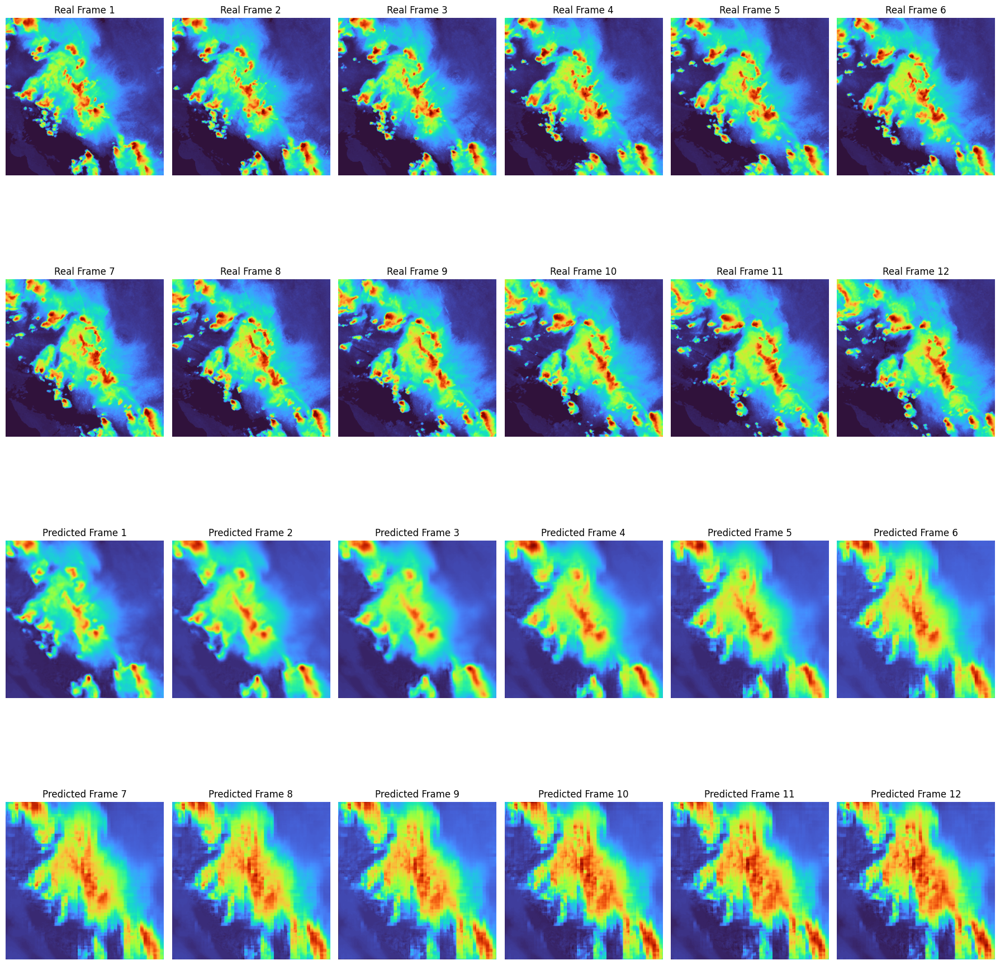

MAE  Error: 0.05041568726301193


In [ ]:
# Load the trained model
model = UNet(input_channels=12, output_channels=12).to(device)
checkpoint = torch.load("/content/drive/MyDrive/saved_model_unet_window/final_model_unet.pth")
checkpoint = torch.load(final_model_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Get the first batch from the validation loader
for batch_idx, batch in enumerate(val_loader1):  # Use ⁠ val_loader1 ⁠ or test DataLoader
    if batch_idx == 0:  # Only process the first batch
        # Get inputs and targets, remove the singleton channel dimension
        inputs, targets = batch['input'].to(device), batch['output'].to(device)

        # Reshape the input and output tensors to remove the channel dimension
        inputs = inputs.squeeze(2)  # Reshape from [batch_size, temporal_frames, 1, height, width] to [batch_size, temporal_frames, height, width]
        targets = targets.squeeze(2)  # Same for the target

        print(f"Input shape after squeeze: {inputs.shape}, Target shape after squeeze: {targets.shape}")

        # Make predictions using the model
        with torch.no_grad():  # No need to calculate gradients for predictions
            predicted_output = model(inputs)  # Pass the input data through the model

        # Visualize the comparison of the predicted vs real output for all 12 frames
        num_frames = 12  # Total frames in the sequence (12 frames)

        # Create a figure with 4 rows and 6 columns
        plt.figure(figsize=(18, 20))  # Adjusted figure size for four rows of 6 images

        # Plot the real output frames (ground truth) in the first two rows
        for frame_idx in range(num_frames):
            # Plot in the first 2 rows, 6 columns
            plt.subplot(4, 6, frame_idx + 1)  # 4 rows, 6 columns, first row
            plt.imshow(targets[0, frame_idx, :, :].cpu().numpy(), cmap='gray')  # Real output frame
            plt.title(f'Real Frame {frame_idx + 1}')
            plt.axis('off')

        # Plot the predicted output frames starting from the 3rd row
        for frame_idx in range(num_frames):
            # Plot in the 3rd and 4th rows, 6 columns
            plt.subplot(4, 6, 12 + frame_idx + 1)  # 4 rows, 6 columns, 3rd row
            plt.imshow(predicted_output[0, frame_idx, :, :].cpu().numpy(), cmap='gray')  # Predicted frame
            plt.title(f'Predicted Frame {frame_idx + 1}')
            plt.axis('off')

        plt.tight_layout()  # Adjust layout
        plt.show()

        l1_loss = torch.nn.L1Loss()(predicted_output, targets)
        print(f'Mean Squared Error: {l1_loss.item()}')

        break  # Only process the first batch, stop after the first batch

<ipython-input-34-b3a5b94c4c45>:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("/content/drive/MyDrive/saved_model_unet_window/final_model_unet.pt

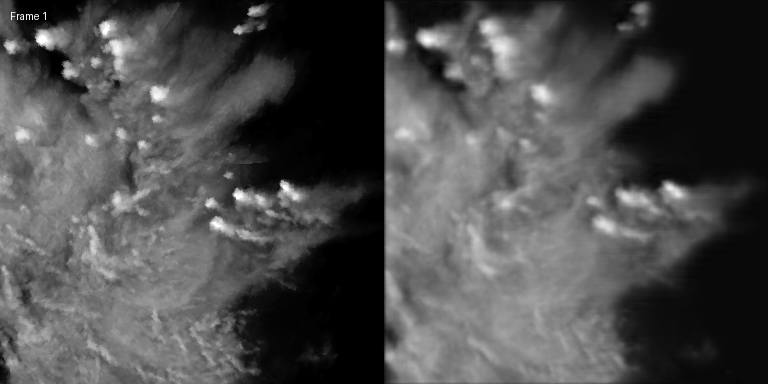

GIF saved and displayed at /content/drive/MyDrive/comparison.gif


In [ ]:
# Load data
h5_file = 'data/train.h5'  # Path to your .h5 file
img_type = 'vil'  # The image type you want to load (e.g., 'vis', 'ir069', etc.)

# Device to cuda
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define datasets
dataset1 = H5Dataset1(h5_file=h5_file, img_type=img_type, input_frames=12, output_frames=12, height=384, width=384)
all_indices = list(range(len(dataset1)))
train_indices1, val_indices1 = split_data(all_indices, train_ratio=0.8)
train_dataset1 = Subset(dataset1, train_indices1)
val_dataset1 = Subset(dataset1, val_indices1)

# Define dataloaders
batch_size = 64
train_loader1 = DataLoader(train_dataset1, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_loader1 = DataLoader(val_dataset1, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

# Load the trained model
model = UNet(input_channels=12, output_channels=12).to(device)
checkpoint = torch.load("/content/drive/MyDrive/saved_model_unet_window/final_model_unet.pth")
checkpoint = torch.load(final_model_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Function to create and display GIF inline
def make_gif(outfile, frames, fps=10, loop=0):
    imageio.mimsave(outfile, frames, duration=int(1000 / fps))
    return display.Image(filename=outfile)

# Get the first batch from the validation loader
for batch_idx, batch in enumerate(val_loader1):
    if batch_idx == 0:  # Only process the first batch
        inputs, targets = batch['input'].to(device), batch['output'].to(device)
        inputs = inputs.squeeze(2)  # Remove singleton channel dimension
        targets = targets.squeeze(2)

        with torch.no_grad():
            predicted_output = model(inputs)

        num_frames = 12
        frames = []
        for frame_idx in range(num_frames):
            real_frame = targets[0, frame_idx, :, :].cpu().numpy()
            pred_frame = predicted_output[0, frame_idx, :, :].cpu().numpy()

            # Normalize for visualization
            real_frame = (real_frame - real_frame.min()) / (real_frame.max() - real_frame.min())
            pred_frame = (pred_frame - pred_frame.min()) / (pred_frame.max() - pred_frame.min())

            combined_frame = np.hstack((real_frame, pred_frame))  # Concatenate real and predicted
            image = (combined_frame * 255).astype(np.uint8)

            # Convert to PIL Image and add frame number
            img_pil = Image.fromarray(image)
            draw = ImageDraw.Draw(img_pil)
            draw.text((10, 10), f"Frame {frame_idx+1}", fill=255)
            frames.append(img_pil)

        # Save and display GIF inline with looping enabled
        gif_path = "/content/drive/MyDrive/comparison.gif"
        im = make_gif(gif_path, frames, fps=5, loop=0)
        display.display(im)
        print(f"GIF saved and displayed at {gif_path}")
        break
